# Worksheet-4 Solution
## Building Fully Connected Neural Networks for Devnagari Handwritten Digit Classification.

**Module:** Artificial Intelligence and Machine Learning  
**Institution:** Herald College Kathmandu  
**Submitted Date:** April 01, 2026

---

### Student Details

| Name | ID Number | Group |
| :--- | :--- | :--- |
| **Narayan Lohani** | 2408869 | L6CG15 |

---

<div style="display: flex; justify-content: space-between; align-items: center; border: none;">
  <img src="https://heraldcollege.edu.np/images/footer/footer-logo-dark.svg" width="180" alt="Herald College Logo">
  <img src="
  https://bizzeducation.com/storage/university-partners/May2024/r3iG0n8CHfh1nCAIz5BO.png" width="180" alt="University of Wolverhampton Logo">
</div>


In [ ]:
import tensorflow as tf
import keras
import numpy as np

# Verify TensorFlow is correctly installed and display its version
print(f"✅ TensorFlow version: {tf.__version__}")


✅ TensorFlow version: 2.21.0


# Task 1: Data Preparation
------------------------

### Loading the Data

-   Download the provided folder that contains the Devnagari digits dataset.

-   Use the **Python Imaging Library (PIL)** to load and read the image files form the dataset.

-   Convert the images into **Numpy arrays** and normalize them to a range of $0-1$.

-   Use the `train` folder for training and `test` for testing.

-   Extract the corresponding labels for each image.

 **Hints:**

 -   Ensure that the images are resized to a consistent shape (e.g., $28 \times 28$).

 -   Convert labels to **one-hot encoded** format for multi-class classification.

In [ ]:
# Set the directory paths for training and testing data
train_dir = "DevanagariHandwrittenDigitDataset/Train/"
test_dir = "DevanagariHandwrittenDigitDataset/Test/"

# Define the target image size; all images are resized to this uniform shape.
# The Devanagari dataset images are standardised to 28×28 pixels.
img_height, img_width = 28, 28


In [ ]:
import os
from PIL import Image


def load_images_from_folder(folder):
    """
    Load images and their corresponding labels from a class-structured folder.

    The folder is expected to contain subdirectories, one per digit class
    (e.g., digit_0, digit_1, …, digit_9). Each subdirectory holds the image
    files that belong to that class.

    Args:
        folder (str): Path to the root dataset directory that contains
                      class-named subdirectories.

    Returns:
        tuple[np.ndarray, np.ndarray]: A two-element tuple ``(images, labels)``
            where:

            * **images** - Float array of shape ``(N, img_height, img_width)``
              with pixel values normalised to the range [0, 1].
            * **labels** - Integer array of shape ``(N,)`` holding the class
              index for each image (assigned by sorted directory order).
    """
    images = []
    labels = []

    # Sort class directory names so the label mapping is deterministic
    # (e.g., digit_0 → 0, digit_1 → 1, …, digit_9 → 9)
    class_names = sorted(os.listdir(folder))

    # Build a dictionary that maps each class name to its integer index
    class_map = {name: i for i, name in enumerate(class_names)}

    # Iterate over every class folder and load its images
    for class_name in class_names:
        class_path = os.path.join(folder, class_name)  # Full path to the class dir
        label = class_map[class_name]  # Integer label for this class

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            # Open image and convert to grayscale
            img = Image.open(img_path).convert("L")

            # Resize to the target dimensions to ensure a consistent input shape
            img = img.resize((img_width, img_height))  # Resize to (28, 28)

            # Convert PIL image → NumPy array and normalise pixel values to [0, 1]
            img = np.array(img) / 255.0  # Normalize pixel values to [0,1]

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)


Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set:  (3000, 28, 28, 1),  Labels: (3000, 10)


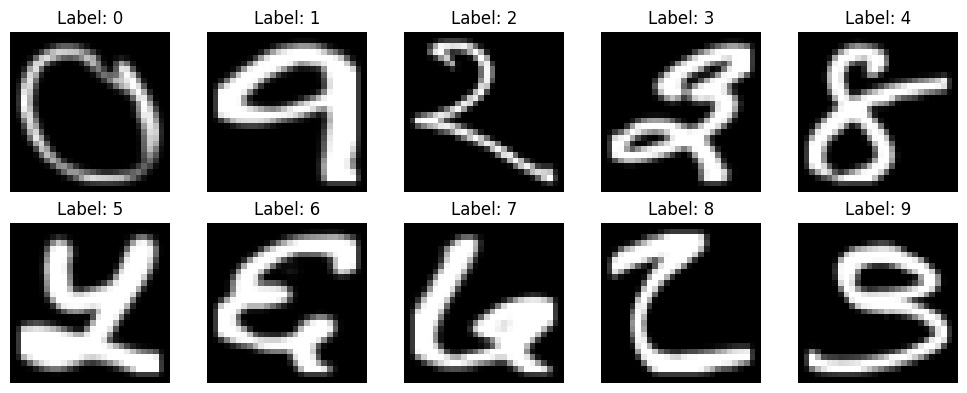

In [ ]:
import matplotlib.pyplot as plt
from keras.utils import to_categorical

# Load raw images and integer labels from disk using the helper function
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images to add the channel dimension required by Keras:
# (num_samples, height, width) → (num_samples, height, width, channels)
# For grayscale images the channel count is 1.
x_train = x_train.reshape(-1, img_height, img_width, 1)  # (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# Convert integer class labels to one-hot encoded vectors so they match the
# softmax output of the model (e.g., label 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0])
y_train = to_categorical(y_train, num_classes=10)  # One-hot encode labels
y_test = to_categorical(y_test, num_classes=10)

# Print dataset shape to verify successful loading and preprocessing
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set:  {x_test.shape},  Labels: {y_test.shape}")

# Visualise one sample image per digit class (0–9)
plt.figure(figsize=(10, 4))
true_labels = np.argmax(y_train, axis=1)  # convert one-hot back to integer labels

for digit in range(10):
    # Find the index of the first training sample whose true label matches 'digit'
    idx = np.where(true_labels == digit)[0][0]
    plt.subplot(2, 5, digit + 1)
    plt.imshow(x_train[idx].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {digit}")
    plt.axis("off")

plt.tight_layout()
plt.show()


# Task 2: Build the FCN Model
---------------------------

### Model Architecture

-   Create a **Sequential** model using Keras.

-   Add **3 hidden layers** with the following neurons:

    1.  **1st hidden layer:** 64 neurons

    2.  **2nd hidden layer:** 128 neurons

    3.  **3rd hidden layer:** 256 neurons

-   Use **Sigmoid** activation functions for all hidden layers.

-   Add an **output layer** with **10 units** (since Devnagari digits have 10 classes) and a softmax activation function.

In [ ]:
# Total number of Devanagari digit classes (digits 0–9)
num_classes = 10

# Input shape: 28×28 grayscale images with a single channel
input_shape = (28, 28, 1)

# Build a Sequential Fully Connected Network (FCN):
#   Flatten  : flattens the 28×28×1 image into a 784-element vector
#   Dense 64 : 1st hidden layer — 64 neurons, sigmoid activation
#   Dense 128: 2nd hidden layer — 128 neurons, sigmoid activation
#   Dense 256: 3rd hidden layer — 256 neurons, sigmoid activation
#   Dense 10 : output layer    — one neuron per class, softmax gives probabilities
model = keras.Sequential(
    [
        keras.layers.Input(shape=input_shape),
        keras.layers.Flatten(),  # Flatten 28x28x1 → 784
        keras.layers.Dense(64, activation="sigmoid"),  # 1st hidden layer
        keras.layers.Dense(128, activation="sigmoid"),  # 2nd hidden layer
        keras.layers.Dense(256, activation="sigmoid"),  # 3rd hidden layer
        keras.layers.Dense(num_classes, activation="softmax"),  # Output layer
    ]
)

# Display model architecture and total trainable parameter count
model.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

# Task 3: Compile the Model
---------------------------

### Model Compilation
- Choose an appropriate **optimizer** `(e.g., Adam)`, l**oss function** `(e.g., sparse_categorical_crossentropy)`, and **evalutional metric** `(e.g., accuracy)`.

In [ ]:
model.compile(
    optimizer="adam",  # Adam optimiser — adaptive learning rate
    loss="categorical_crossentropy",  # Standard loss for one-hot multi-class targets
    metrics=["accuracy"],  # Track classification accuracy each epoch
)
print("Model compiled successfully.")


Model compiled successfully.


Task 4: Train the Model
-----------------------

### Model Training

-   Use `model.fit()` to train the model. Set the **batch size to 128** and the number of **epochs to 20**.

-   Use **validation split of 0.2** to monitor model's performance on validation data.

-   Optionally, use callbacks such as `ModelCheckpoint` and `EarlyStopping` for saving the best model and avoiding overfitting.

In [ ]:
batch_size = 128  # Number of samples per gradient update
epochs = 20  # Maximum number of full passes over the training data

# Callbacks applied at the end of each epoch
callbacks = [
    # Save the model weights after every epoch so the best checkpoint is preserved
    keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
    # Stop training early if validation loss does not improve for 4 consecutive
    # epochs, preventing overfitting and unnecessary computation
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4),
]

# Shuffle the training dataset to remove any ordering bias before training
indices = np.arange(x_train.shape[0])
np.random.shuffle(indices)
x_train = x_train[indices]
y_train = y_train[indices]

# Train the model; reserve 15 % of training data as the validation split.
# The validation set is used to monitor generalisation after every epoch.
history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.15,  # 15 % of training data held out for validation
    callbacks=callbacks,
)


Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4554 - loss: 1.8048 - val_accuracy: 0.7796 - val_loss: 0.9930
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step - accuracy: 0.8297 - loss: 0.6063 - val_accuracy: 0.9027 - val_loss: 0.3865
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9088 - loss: 0.3173 - val_accuracy: 0.9302 - val_loss: 0.2551
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9390 - loss: 0.2209 - val_accuracy: 0.9471 - val_loss: 0.1957
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 944us/step - accuracy: 0.9552 - loss: 0.1653 - val_accuracy: 0.9549 - val_loss: 0.1634
Epoch 6/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 949us/step - accuracy: 0.9651 - loss: 0.1301 - val_accuracy: 0.9616 - val_loss: 0.1360
Epoch 7/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9727 - loss: 0.1060 - val_accuracy: 0.9663 - val_loss: 0.1219
Epoch 8/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9765 - loss: 0.0886 - val_accura

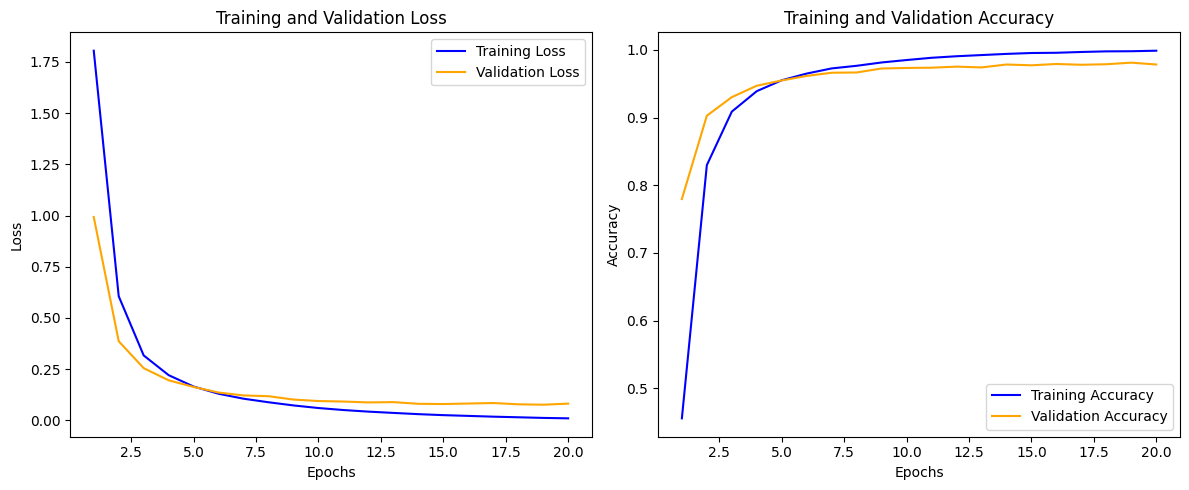

In [ ]:
# Extract per-epoch training and validation loss from the history object
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

# Extract per-epoch training and validation accuracy
train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

# Loss curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label="Training Loss", color="blue")
plt.plot(range(1, len(val_loss) + 1), val_loss, label="Validation Loss", color="orange")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(
    range(1, len(train_acc) + 1), train_acc, label="Training Accuracy", color="blue"
)
plt.plot(
    range(1, len(val_acc) + 1), val_acc, label="Validation Accuracy", color="orange"
)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


# Task 5: Evaluate the Model
--------------------------

### Model Evaluation

-   After training, evaluate the model using `model.evaluate()` on the test set to check the test accuracy and loss.

In [ ]:
# Shuffle the test set so that the spot-check below is not biased toward any
# particular digit ordering
indices = np.arange(x_test.shape[0])
np.random.shuffle(indices)
x_test = x_test[indices]
y_test = y_test[indices]

# Evaluate the trained model on the held-out test set to measure generalisation.
# verbose=2 prints one summary line per step (suppresses the progress bar).
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


94/94 - 0s - 408us/step - accuracy: 0.9813 - loss: 0.0742
Test Loss:     0.0742
Test Accuracy: 0.9813


# Task 6: Save and Load the Model
-------------------------------

### Model Saving and Loading

-   Save the trained model to an `.h5` file using `model.save()`.

-   Load the saved model and re-evaluate its performance on the test set.

In [ ]:
# Persist the trained model (architecture + weights) to an HDF5 (.h5) file.
# This allows the model to be restored later without retraining.
path_to_model = "models/devnagari_fully_connected_model.h5"
model.save(path_to_model)
print("Model saved to 'devnagari_fully_connected_model.h5'")


Model saved to 'devnagari_fully_connected_model.h5'


In [ ]:
# Reload the persisted model from disk (architecture + weights)
loaded_model = keras.models.load_model(path_to_model)
print("Model loaded successfully.")

# Re-evaluate the loaded model to confirm it produces identical results to the original, verifying that the save/load round-trip was lossless.
loaded_loss, loaded_acc = loaded_model.evaluate(x_train, y_train, verbose=2)
print(f"Loaded Model — Test Loss: {loaded_loss:.4f} | Test Accuracy: {loaded_acc:.4f}")


Model loaded successfully.
532/532 - 0s - 473us/step - accuracy: 0.9963 - loss: 0.0186
Loaded Model — Test Loss: 0.0186 | Test Accuracy: 0.9963


# Task 7: Predictions
-------------------

### Making Predictions

-   Use `model.predict()` to make predictions on test images.

-   Convert the model's predicted probabilities to digit labels using `np.argmax()`.

In [ ]:
# Run the model over the entire test set; returns a softmax probability
# distribution across the 10 digit classes for every sample
predictions = model.predict(x_test)

# Convert probability vectors to the predicted class index (digit with highest probability)
predicted_labels = np.argmax(predictions, axis=1)

# Spot-check: display the prediction and ground-truth for the first test image
print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image:      {np.argmax(y_test[0])}")


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 430us/step
Predicted label for first image: 3
True label for first image:      3


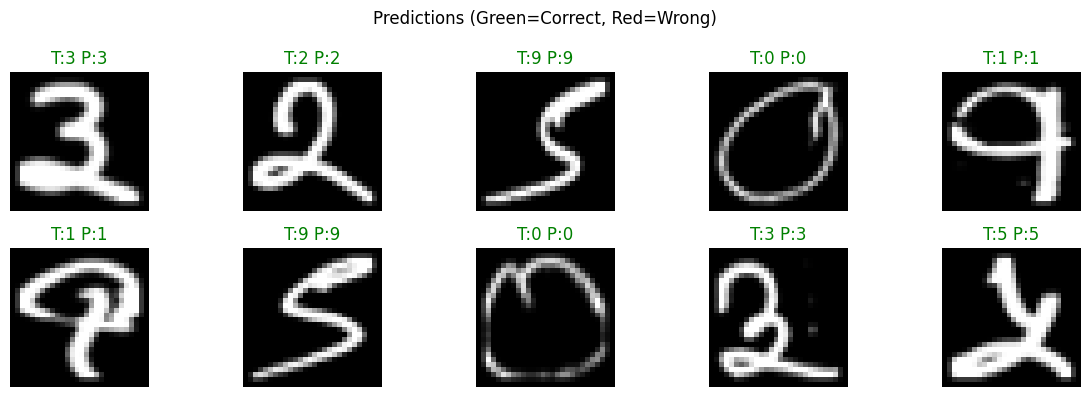

In [ ]:
# Visualise predictions for the first 10 test images.
# Title colour indicates correctness: green = correct, red = incorrect.
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")

    true_label = np.argmax(y_test[i])  # Ground-truth digit label
    pred_label = predicted_labels[i]  # Model's predicted digit label

    # Choose title colour based on whether the prediction is correct
    colour = "green" if pred_label == true_label else "red"
    plt.title(f"T:{true_label} P:{pred_label}", color=colour)
    plt.axis("off")

plt.suptitle("Predictions (Green=Correct, Red=Wrong)", fontsize=12)
plt.tight_layout()
plt.show()
